In [1]:
# Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

import joblib
import json

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Defined paths
icu_path = r"C:\Users\nefig\OneDrive\Documents\Data Science Related\Data Science Master's Program\Case Studies in Data Science\Guevara_Nefi_Assignment1_Code\icu"
hosp_path = r"C:\Users\nefig\OneDrive\Documents\Data Science Related\Data Science Master's Program\Case Studies in Data Science\Guevara_Nefi_Assignment1_Code\hosp"

In [3]:
# Verify files
print("ICU files:", os.listdir(icu_path))
print("HOSP files:", os.listdir(hosp_path))

ICU files: ['caregiver.csv.gz', 'chartevents.csv.gz', 'datetimeevents.csv.gz', 'd_items.csv.gz', 'icustays.csv.gz', 'ingredientevents.csv.gz', 'inputevents.csv.gz', 'outputevents.csv.gz', 'procedureevents.csv.gz']
HOSP files: ['admissions.csv.gz', 'diagnoses_icd.csv.gz', 'drgcodes.csv.gz', 'd_hcpcs.csv.gz', 'd_icd_diagnoses.csv.gz', 'd_icd_procedures.csv.gz', 'd_labitems.csv.gz', 'emar.csv.gz', 'emar_detail.csv.gz', 'hcpcsevents.csv.gz', 'labevents.csv.gz', 'microbiologyevents.csv.gz', 'omr.csv.gz', 'patients.csv.gz', 'pharmacy.csv.gz', 'poe.csv.gz', 'poe_detail.csv.gz', 'prescriptions.csv.gz', 'procedures_icd.csv.gz', 'provider.csv.gz', 'services.csv.gz', 'transfers.csv.gz']


In [4]:
# Load data
icustays = pd.read_csv(os.path.join(icu_path, "icustays.csv.gz"), compression='gzip')
patients = pd.read_csv(os.path.join(hosp_path, "patients.csv.gz"), compression='gzip')
admissions = pd.read_csv(os.path.join(hosp_path, "admissions.csv.gz"), compression='gzip')
labevents = pd.read_csv(os.path.join(hosp_path, "labevents.csv.gz"), compression='gzip')
d_labitems = pd.read_csv(os.path.join(hosp_path, "d_labitems.csv.gz"), compression='gzip')

print("Data Loaded!")

Data Loaded!


In [5]:
# Merge ICU + patient data
df = icustays.merge(patients, on='subject_id', how='left')

# Merge admissions
df = df.merge(admissions, on='hadm_id', how='left')

# fixing subject_id unknown parameter issue
df['subject_id'] = df['subject_id_x']
df = df.drop(columns=['subject_id_x', 'subject_id_y'])

In [6]:
# Create features
df['age'] = df['anchor_age']
df['los'] = df['los'].astype(float)
df['mortality'] = df['hospital_expire_flag']

In [7]:
# lab feature engineering
labs = labevents.merge(d_labitems, on='itemid', how='left')

# Example lab features
lactate = labs[labs['label'].str.contains('lactate', case=False, na=False)]
creatinine = labs[labs['label'].str.contains('creatinine', case=False, na=False)]
wbc = labs[labs['label'].str.contains('white blood cell', case=False, na=False)]

# Aggregate first measurement per patient
lactate = lactate.groupby('subject_id')['valuenum'].mean().reset_index().rename(columns={'valuenum': 'lactate'})
creatinine = creatinine.groupby('subject_id')['valuenum'].mean().reset_index().rename(columns={'valuenum': 'creatinine'})
wbc = wbc.groupby('subject_id')['valuenum'].mean().reset_index().rename(columns={'valuenum': 'wbc'})

# Merge labs into df
df = df.merge(lactate, on='subject_id', how='left')
df = df.merge(creatinine, on='subject_id', how='left')
df = df.merge(wbc, on='subject_id', how='left')

In [8]:
# Selecting final features used
df = df[['los', 'age', 'mortality', 'lactate', 'creatinine', 'wbc']]

In [9]:
# Handle missing values
df = df.fillna(df.median(numeric_only=True))

In [10]:
# Train/Test Split
X = df.drop(columns=['los'])
y = df['los']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# Scaling Pipeline
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_train_scaled = pipeline.fit_transform(X_train)
X_test_scaled = pipeline.transform(X_test)

In [12]:
# Baseline Model
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

In [13]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

In [14]:
# Random forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

In [15]:
# Results Comparison
results = pd.DataFrame({
    'Model': ['Baseline', 'Linear Regression', 'Random Forest'],
    'RMSE': [baseline_rmse, lr_rmse, rf_rmse],
    'R2': [None, lr_r2, rf_r2]
})

print(results)

               Model      RMSE        R2
0           Baseline  3.859861       NaN
1  Linear Regression  4.025404 -0.093766
2      Random Forest  4.892644 -0.615819


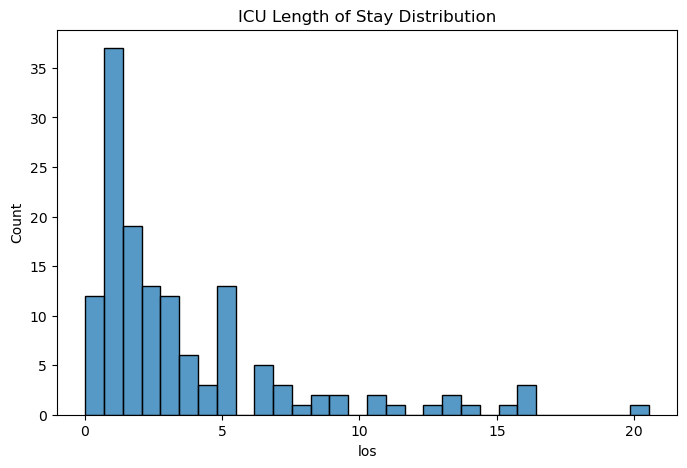

In [16]:
# Visualizations
os.makedirs("results", exist_ok=True)

plt.figure(figsize=(8,5))
sns.histplot(df['los'], bins=30)
plt.title("ICU Length of Stay Distribution")
plt.show()
plt.savefig("results/los_distribution.png")
plt.close()

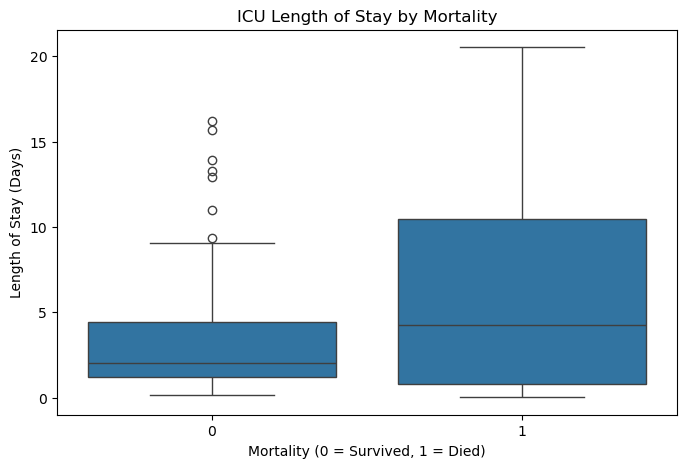

In [17]:
# Length of Stay (LOS) by Mortality
# Patients with mortality outcomes show different LOS distributions
# suggests severity and care intensity influence both survival and resource use
plt.figure(figsize=(8,5))
sns.boxplot(x='mortality', y='los', data=df)

plt.title("ICU Length of Stay by Mortality")
plt.xlabel("Mortality (0 = Survived, 1 = Died)")
plt.ylabel("Length of Stay (Days)")

plt.show()
plt.savefig("results/los_by_mortality.png")
plt.close()

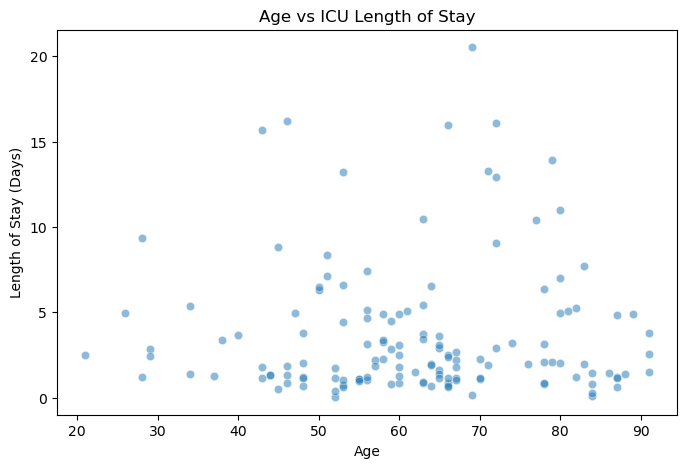

In [18]:
# Age vs LOS
# A weak/moderate relationship may suggest age alone is not a strong predictor, 
# reinforcing the need for clinical + lab features
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='los', data=df, alpha=0.5)

plt.title("Age vs ICU Length of Stay")
plt.xlabel("Age")
plt.ylabel("Length of Stay (Days)")

plt.show()
plt.savefig("results/age_vs_los.png")
plt.close()

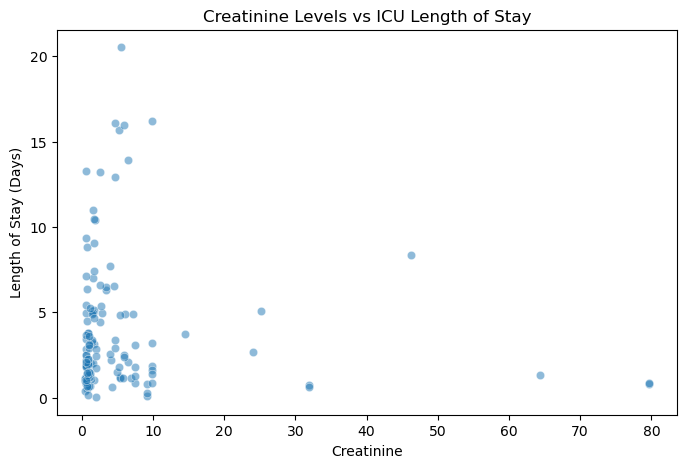

In [19]:
# Lab Values (Creatinine) vs LOS
plt.figure(figsize=(8,5))
sns.scatterplot(x='creatinine', y='los', data=df, alpha=0.5)

plt.title("Creatinine Levels vs ICU Length of Stay")
plt.xlabel("Creatinine")
plt.ylabel("Length of Stay (Days)")

plt.show()
plt.savefig("results/creatinine_vs_los.png")
plt.close()

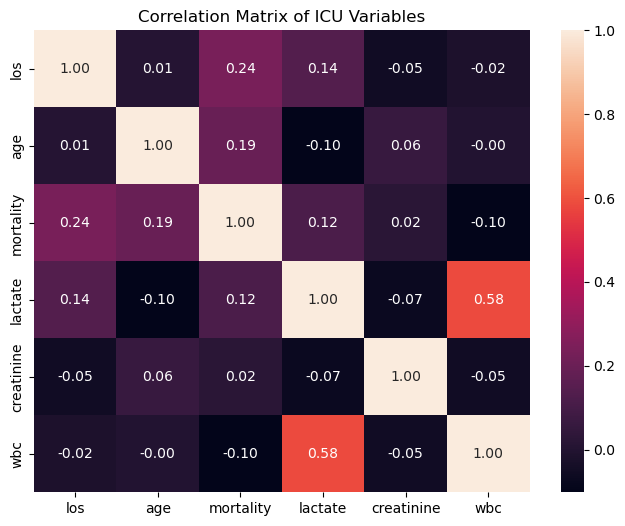

In [20]:
# Correlation Heatmap
# This heatmap highlights relationships between clinical variables and LOS, 
# helping identify the most influential predictors for modeling
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")

plt.title("Correlation Matrix of ICU Variables")

plt.show()
plt.savefig("results/correlation_matrix.png")
plt.close()

In [21]:
# Saving Datasets
os.makedirs("data/processed", exist_ok=True)

train_df = X_train.copy()
train_df['los'] = y_train

test_df = X_test.copy()
test_df['los'] = y_test

train_df.to_csv("data/processed/train_dataset.csv", index=False)
test_df.to_csv("data/processed/test_dataset.csv", index=False)

In [22]:
# Saving Model
os.makedirs("models", exist_ok=True)

joblib.dump(rf, "models/random_forest_model.pkl")

['models/random_forest_model.pkl']

In [23]:
# Saving metrics
metrics = {
    "baseline_rmse": float(baseline_rmse),
    "linear_regression_rmse": float(lr_rmse),
    "linear_regression_r2": float(lr_r2),
    "random_forest_rmse": float(rf_rmse),
    "random_forest_r2": float(rf_r2)
}

with open("results/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

# Printing Results
print(results)
print("Finished Modeling Analysis")

               Model      RMSE        R2
0           Baseline  3.859861       NaN
1  Linear Regression  4.025404 -0.093766
2      Random Forest  4.892644 -0.615819
Finished Modeling Analysis
